# 🤖 Notebook 2 — Classical ML Models
**Malicious URL Detection | ISCX-URL2016**

This notebook trains and evaluates:
- Logistic Regression, Naive Bayes, K-NN, Decision Tree
- Random Forest, XGBoost, LightGBM, AdaBoost, SVM
- Per-class and global metrics (Accuracy, Precision, Recall, F1, FPR, ROC-AUC)




## 0 · Setup

In [3]:
!pip install -q imbalanced-learn lightgbm xgboost scikit-learn pandas numpy matplotlib seaborn

from google.colab import drive
drive.mount('/content/drive')

import os, json, pickle, warnings
warnings.filterwarnings('ignore')

SAVE_DIR = '/content/drive/MyDrive/ESI TPs/sec_miniProject/Detection_of_Malicious_URLs/output/'
MODEL_DIR = '/content/drive/MyDrive/ESI TPs/sec_miniProject/Detection_of_Malicious_URLs/models/'
os.makedirs(MODEL_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1 · Load Processed Data

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(SAVE_DIR + 'processed_data.csv')
with open(SAVE_DIR + 'label_map.json') as f:
    label_map = {int(k): v for k, v in json.load(f).items()}

X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print('Classes:', label_map)

Train: (29365, 40) | Test: (7342, 40)
Classes: {0: 'Defacement', 1: 'benign', 2: 'malware', 3: 'phishing', 4: 'spam'}


## 2 · SMOTE — Handle Class Imbalance

In [5]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

print('After SMOTE:')
vals, cnts = np.unique(y_train_sm, return_counts=True)
for v, c in zip(vals, cnts):
    print(f'  {label_map[v]:15s}: {c}')

After SMOTE:
  Defacement     : 6344
  benign         : 6344
  malware        : 6344
  phishing       : 6344
  spam           : 6344


## 3 · Metric Utilities

In [6]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score, recall_score
)
import matplotlib.pyplot as plt
import seaborn as sns

def compute_fpr_macro(y_true, y_pred, n_classes):
    """Macro-averaged False Positive Rate (one-vs-rest)."""
    fprs = []
    for c in range(n_classes):
        yt = (y_true == c).astype(int)
        yp = (y_pred == c).astype(int)
        cm = confusion_matrix(yt, yp)
        tn, fp = cm[0, 0], cm[0, 1]
        fprs.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
    return np.mean(fprs)

def evaluate(name, model, X_tr, y_tr, X_te, y_te, proba=True, results_dict=None):
    y_pred  = model.predict(X_te)
    acc     = accuracy_score(y_te, y_pred)
    f1      = f1_score(y_te, y_pred, average='macro')
    fpr     = compute_fpr_macro(y_te.values if hasattr(y_te,'values') else y_te, y_pred, len(label_map))
    try:
        auc = roc_auc_score(y_te, model.predict_proba(X_te), multi_class='ovr', average='macro') if proba else None
    except Exception:
        auc = None

    print(f'\n{'='*55}')
    print(f'  {name}')
    print(f'{'='*55}')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Macro F1 : {f1:.4f}')
    print(f'  Macro FPR: {fpr:.4f}')
    if auc: print(f'  ROC-AUC  : {auc:.4f}')
    print(classification_report(y_te, y_pred,
          target_names=[label_map[i] for i in sorted(label_map)]))

    if results_dict is not None:
        results_dict[name] = {'Accuracy': acc, 'Macro F1': f1,
                               'Macro FPR': fpr, 'ROC-AUC': auc}
    return y_pred

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    labels = [label_map[i] for i in sorted(label_map)]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(title, fontweight='bold')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout(); plt.show()

results = {}
n_classes = len(label_map)
print('Utility functions ready.')

Utility functions ready.


## 4 · Train Classifiers

### 4.1 Logistic Regression


  Logistic Regression
  Accuracy : 0.8001
  Macro F1 : 0.7991
  Macro FPR: 0.0501
  ROC-AUC  : 0.9591
              precision    recall  f1-score   support

  Defacement       0.83      0.78      0.80      1586
      benign       0.80      0.84      0.81      1556
     malware       0.72      0.69      0.70      1343
    phishing       0.77      0.81      0.79      1517
        spam       0.88      0.89      0.89      1340

    accuracy                           0.80      7342
   macro avg       0.80      0.80      0.80      7342
weighted avg       0.80      0.80      0.80      7342



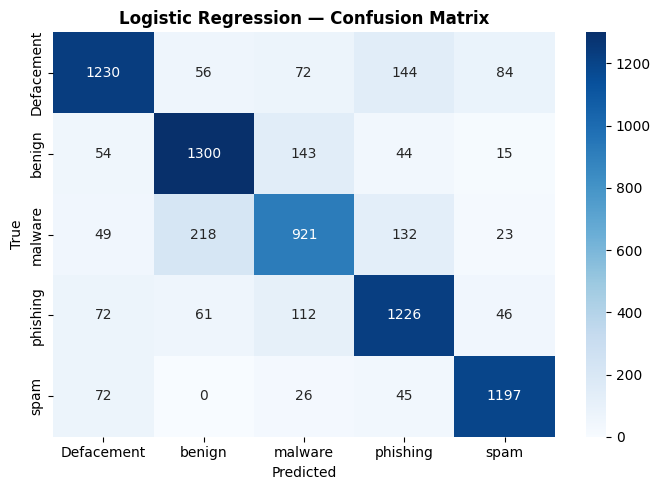

In [7]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs',
                         multi_class='multinomial', n_jobs=-1, random_state=42)
lr.fit(X_train_sm, y_train_sm)
y_pred_lr = evaluate('Logistic Regression', lr, X_train_sm, y_train_sm,
                      X_test_sc, y_test, results_dict=results)
plot_cm(y_test, y_pred_lr, 'Logistic Regression — Confusion Matrix')

### 4.2 Decision Tree


  Decision Tree
  Accuracy : 0.9516
  Macro F1 : 0.9517
  Macro FPR: 0.0121
  ROC-AUC  : 0.9758
              precision    recall  f1-score   support

  Defacement       0.96      0.97      0.97      1586
      benign       0.96      0.97      0.97      1556
     malware       0.96      0.96      0.96      1343
    phishing       0.92      0.89      0.90      1517
        spam       0.96      0.96      0.96      1340

    accuracy                           0.95      7342
   macro avg       0.95      0.95      0.95      7342
weighted avg       0.95      0.95      0.95      7342



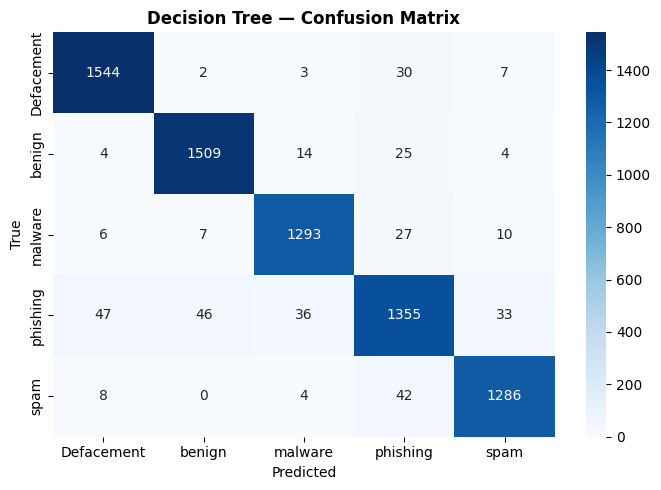

In [8]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=20, min_samples_split=5,
                              criterion='gini', random_state=42)
dt.fit(X_train_sm, y_train_sm)
y_pred_dt = evaluate('Decision Tree', dt, X_train_sm, y_train_sm,
                      X_test_sc, y_test, results_dict=results)
plot_cm(y_test, y_pred_dt, 'Decision Tree — Confusion Matrix')

### 4.3 Random Forest


  Random Forest
  Accuracy : 0.9752
  Macro F1 : 0.9755
  Macro FPR: 0.0062
  ROC-AUC  : 0.9990
              precision    recall  f1-score   support

  Defacement       0.99      0.98      0.98      1586
      benign       0.98      0.99      0.98      1556
     malware       1.00      0.97      0.98      1343
    phishing       0.93      0.97      0.95      1517
        spam       0.99      0.96      0.98      1340

    accuracy                           0.98      7342
   macro avg       0.98      0.97      0.98      7342
weighted avg       0.98      0.98      0.98      7342



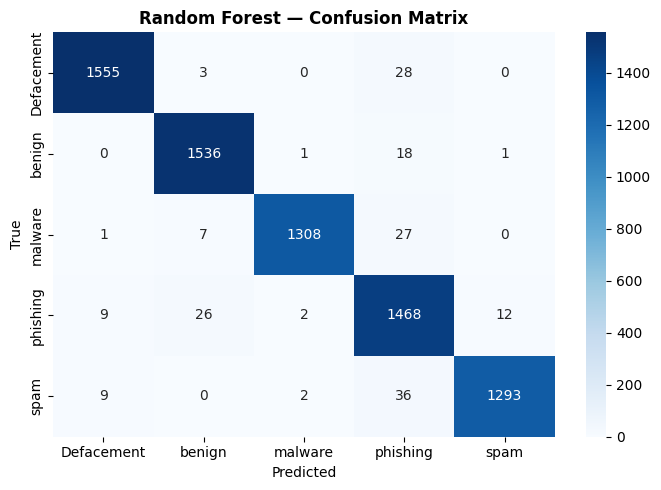

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_leaf=2,
                              n_jobs=-1, class_weight='balanced', random_state=42)
rf.fit(X_train_sm, y_train_sm)
y_pred_rf = evaluate('Random Forest', rf, X_train_sm, y_train_sm,
                      X_test_sc, y_test, results_dict=results)
plot_cm(y_test, y_pred_rf, 'Random Forest — Confusion Matrix')

### 4.4 XGBoost

[0]	validation_0-mlogloss:1.51410
[100]	validation_0-mlogloss:0.12040
[200]	validation_0-mlogloss:0.06441
[300]	validation_0-mlogloss:0.05162
[400]	validation_0-mlogloss:0.04780
[499]	validation_0-mlogloss:0.04687

  XGBoost
  Accuracy : 0.9837
  Macro F1 : 0.9838
  Macro FPR: 0.0041
  ROC-AUC  : 0.9995
              precision    recall  f1-score   support

  Defacement       0.99      0.99      0.99      1586
      benign       0.98      0.99      0.98      1556
     malware       0.99      0.99      0.99      1343
    phishing       0.96      0.96      0.96      1517
        spam       0.99      0.99      0.99      1340

    accuracy                           0.98      7342
   macro avg       0.98      0.98      0.98      7342
weighted avg       0.98      0.98      0.98      7342



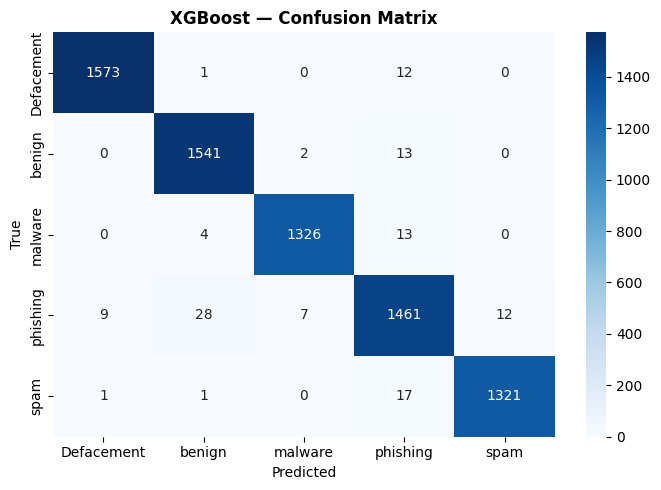

In [10]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=8,
    subsample=0.8, colsample_bytree=0.8, gamma=0.1,
    use_label_encoder=False, eval_metric='mlogloss',
    tree_method='hist', device='cuda',   # uses GPU if available
    n_jobs=-1, random_state=42
)
xgb.fit(X_train_sm, y_train_sm,
        eval_set=[(X_test_sc, y_test)], verbose=100)
y_pred_xgb = evaluate('XGBoost', xgb, X_train_sm, y_train_sm,
                       X_test_sc, y_test, results_dict=results)
plot_cm(y_test, y_pred_xgb, 'XGBoost — Confusion Matrix')

### 4.5 LightGBM


  LightGBM
  Accuracy : 0.9873
  Macro F1 : 0.9874
  Macro FPR: 0.0032
  ROC-AUC  : 0.9996
              precision    recall  f1-score   support

  Defacement       0.99      1.00      1.00      1586
      benign       0.98      0.99      0.99      1556
     malware       1.00      0.99      0.99      1343
    phishing       0.97      0.97      0.97      1517
        spam       0.99      0.98      0.99      1340

    accuracy                           0.99      7342
   macro avg       0.99      0.99      0.99      7342
weighted avg       0.99      0.99      0.99      7342



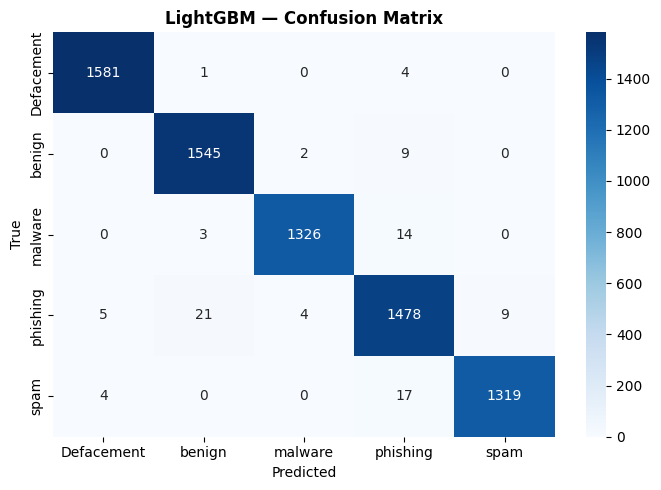

In [11]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=10,
    num_leaves=63, subsample=0.8, colsample_bytree=0.8,
    min_child_samples=20, class_weight='balanced',
    device='gpu',   # uses GPU if available, else falls back to CPU
    n_jobs=-1, random_state=42, verbose=-1
)
lgbm.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test_sc, y_test)],
    callbacks=[]
)
y_pred_lgbm = evaluate('LightGBM', lgbm, X_train_sm, y_train_sm,
                        X_test_sc, y_test, results_dict=results)
plot_cm(y_test, y_pred_lgbm, 'LightGBM — Confusion Matrix')

## 5 · Comparison Table


🏆 MODEL COMPARISON
                     Accuracy  Macro F1  Macro FPR  ROC-AUC
LightGBM               0.9873    0.9874     0.0032   0.9996
XGBoost                0.9837    0.9838     0.0041   0.9995
Random Forest          0.9752    0.9755     0.0062   0.9990
Decision Tree          0.9516    0.9517     0.0121   0.9758
Logistic Regression    0.8001    0.7991     0.0501   0.9591
SVM (Linear)           0.7700    0.7655     0.0576   0.9478
AdaBoost               0.7126    0.7067     0.0718   0.8930

✅ Best ML model by Accuracy: LightGBM


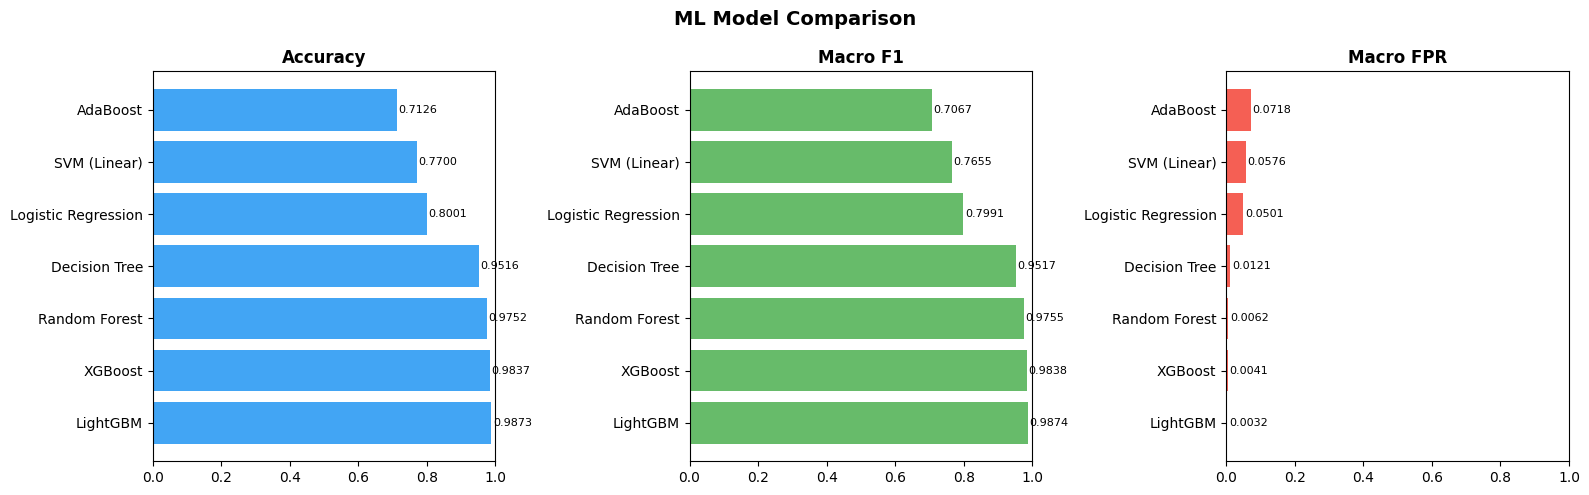

In [14]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('Accuracy', ascending=False)
print('\n🏆 MODEL COMPARISON')
print(results_df.round(4).to_string())

# Highlight best
best_name = results_df.index[0]
print(f'\n✅ Best ML model by Accuracy: {best_name}')

# Save results
results_df.to_csv(MODEL_DIR + 'ml_results.csv')

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['Accuracy', 'Macro F1', 'Macro FPR']
colors  = ['#2196F3', '#4CAF50', '#F44336']
for ax, m, c in zip(axes, metrics, colors):
    vals = results_df[m].dropna().sort_values(ascending=(m=='Macro FPR'))
    ax.barh(vals.index, vals.values, color=c, alpha=0.85)
    ax.set_title(m, fontweight='bold')
    ax.set_xlim(0, 1)
    for i, v in enumerate(vals.values):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=8)
plt.suptitle('ML Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(MODEL_DIR + 'ml_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 · Save Best Models

In [15]:
# Save best 3 models for ensemble
model_registry = {
    'rf'   : rf,
    'xgb'  : xgb,
    'lgbm' : lgbm,
    'scaler': scaler
}
with open(MODEL_DIR + 'ml_models.pkl', 'wb') as f:
    pickle.dump(model_registry, f)

print('✅ Models saved to', MODEL_DIR + 'ml_models.pkl')

✅ Models saved to /content/drive/MyDrive/ESI TPs/sec_miniProject/Detection_of_Malicious_URLs/models/ml_models.pkl
